# Gaussian processes

## Introduction

In supervised learning, we often use parametric models $p(\mathbf{y} \lvert \mathbf{X},\boldsymbol\theta)$ to explain data and infer optimal values of parameter $\boldsymbol\theta$ via maximum likelihood] or [maximum a posteriori](https://de.wikipedia.org/wiki/Maximum_a_posteriori) estimation. If needed we can also infer a full [posterior distribution](https://en.wikipedia.org/wiki/Posterior_probability) $p(\boldsymbol\theta \lvert \mathbf{X},\mathbf{y})$ instead of a point estimate $\boldsymbol{\hat\theta}$. With increasing data complexity, models with a higher number of parameters are usually needed to explain data reasonably well. Methods that use models with a fixed number of parameters are called parametric methods. 

In non-parametric methods, on the other hand, the number of parameters depend on the dataset size. For example, in [Nadaraya-Watson kernel regression](https://en.wikipedia.org/wiki/Kernel_regression), a weight $w_i$ is assigned to each observed target $y_i$ and for predicting the target value at a new point $\mathbf{x}$ a weighted average is computed: 

$$f(\mathbf{x}) = \sum_{i=1}^{N}w_i(\mathbf{x})y_i$$

$$w_i(\mathbf{x}) = \frac{\kappa(\mathbf{x}, \mathbf{x}_{i})}{\sum_{i'=1}^{N}\kappa(\mathbf{x}, \mathbf{x}_{i'})}$$

Observations that are closer to $\mathbf{x}$ have a higher weight than observations that are further away. Weights are computed from $\mathbf{x}$ and observed $\mathbf{x}_i$ with a kernel $\kappa$. A special case is k-nearest neighbors (KNN) where the $k$ closest observations have a weight $1/k$, and all others have weight $0$. Non-parametric methods often need to process all training data for prediction and are therefore slower at inference time than parametric methods. On the other hand, training is usually faster as non-parametric models only need to remember training data. 

Another example of non-parametric methods are [Gaussian processes](https://en.wikipedia.org/wiki/Gaussian_process) (GPs). Instead of inferring a distribution over the parameters of a parametric function Gaussian processes can be used to infer a distribution over functions directly. A Gaussian process defines a prior over functions. After having observed some function values it can be converted into a posterior over functions. Inference of continuous function values in this context is known as GP regression but GPs can also be used for classification. 

A Gaussian process is a [random process](https://en.wikipedia.org/wiki/Stochastic_process) where any point $\mathbf{x} \in \mathbb{R}^d$ is assigned a random variable $f(\mathbf{x})$ and where the joint distribution of a finite number of these variables $p(f(\mathbf{x}_1),...,f(\mathbf{x}_N))$ is itself Gaussian:

$$p(\mathbf{f} \lvert \mathbf{X}) = \mathcal{N}(\mathbf{f} \lvert \boldsymbol\mu, \mathbf{K})\tag{1}\label{eq1}$$

In Equation $(1)$, $\mathbf{f} = (f(\mathbf{x}_1),...,f(\mathbf{x}_N))$, $\boldsymbol\mu = (m(\mathbf{x}_1),...,m(\mathbf{x}_N))$ and $K_{ij} = \kappa(\mathbf{x}_i,\mathbf{x}_j)$. $m$ is the mean function and it is common to use $m(\mathbf{x}) = 0$ as GPs are flexible enough to model the mean arbitrarily well. $\kappa$ is a positive definite *kernel function* or *covariance function*. Thus, a Gaussian process is a distribution over functions whose shape (smoothness, ...) is defined by $\mathbf{K}$. If points $\mathbf{x}_i$ and $\mathbf{x}_j$ are considered to be similar by the kernel the function values at these points, $f(\mathbf{x}_i)$ and $f(\mathbf{x}_j)$, can be expected to be similar too. 

A GP prior $p(\mathbf{f} \lvert \mathbf{X})$ can be converted into a GP posterior $p(\mathbf{f} \lvert \mathbf{X},\mathbf{y})$ after having observed some data $\mathbf{y}$. The posterior can then be used to make predictions $\mathbf{f}_*$ given new input $\mathbf{X}_*$:

$$
\begin{align*}
p(\mathbf{f}_* \lvert \mathbf{X}_*,\mathbf{X},\mathbf{y}) 
&= \int{p(\mathbf{f}_* \lvert \mathbf{X}_*,\mathbf{f})p(\mathbf{f} \lvert \mathbf{X},\mathbf{y})}\ d\mathbf{f} \\ 
&= \mathcal{N}(\mathbf{f}_* \lvert \boldsymbol{\mu}_*, \boldsymbol{\Sigma}_*)\tag{2}\label{eq2}
\end{align*}
$$

Equation $(2)$ is the posterior predictive distribution which is also a Gaussian with mean $\boldsymbol{\mu}_*$ and $\boldsymbol{\Sigma}_*$. By definition of the GP, the joint distribution of observed data $\mathbf{y}$ and predictions $\mathbf{f}_*$  is

$$
\begin{pmatrix}\mathbf{y} \\ \mathbf{f}_*\end{pmatrix} \sim \mathcal{N}
\left(\boldsymbol{0},
\begin{pmatrix}\mathbf{K}_y & \mathbf{K}_* \\ \mathbf{K}_*^T & \mathbf{K}_{**}\end{pmatrix}
\right)\tag{3}\label{eq3}
$$

With $N$ training data and $N_*$ new input data, $\mathbf{K}_y = \kappa(\mathbf{X},\mathbf{X}) + \sigma_y^2\mathbf{I} = \mathbf{K} + \sigma_y^2\mathbf{I}$ is $N \times N$, $\mathbf{K}_* = \kappa(\mathbf{X},\mathbf{X}_*)$ is $N \times N_*$ and $\mathbf{K}_{**} = \kappa(\mathbf{X}_*,\mathbf{X}_*)$ is $N_* \times N_*$. $\sigma_y^2$ is the noise term in the diagonal of $\mathbf{K_y}$. It is set to zero if training targets are noise-free and to a value greater than zero if observations are noisy. The mean is set to $\boldsymbol{0}$ for notational simplicity. The sufficient statistics of the posterior predictive distribution, $\boldsymbol{\mu}_*$ and $\boldsymbol{\Sigma}_*$, can be computed with<sup>[1][3]</sup>

$$
\begin{align*}
\boldsymbol{\mu_*} &= \mathbf{K}_*^T \mathbf{K}_y^{-1} \mathbf{y}\tag{4}\label{eq4} \\
\boldsymbol{\Sigma_*} &= \mathbf{K}_{**} - \mathbf{K}_*^T \mathbf{K}_y^{-1} \mathbf{K}_*\tag{5}\label{eq5}
\end{align*}
$$

This is the minimum we need to know for implementing Gaussian processes and applying them to regression problems. For further details, please consult the literature in the [References](#References) section. The next section shows how to implement GPs with plain NumPy from scratch, later sections demonstrate how to use GP implementations from [scikit-learn](http://scikit-learn.org/stable/) and [GPy](http://sheffieldml.github.io/GPy/).

## Implementation with NumPy

Here, we will use the squared exponential kernel, also known as Gaussian kernel or RBF kernel:

$$
\kappa(\mathbf{x}_i,\mathbf{x}_j) = \sigma_f^2 \exp(-\frac{1}{2l^2}
  (\mathbf{x}_i - \mathbf{x}_j)^T
  (\mathbf{x}_i - \mathbf{x}_j))\tag{6}
$$

The length parameter $l$ controls the smoothness of the function and $\sigma_f$ the vertical variation. For simplicity, we use the same length parameter $l$ for all input dimensions (isotropic kernel). 

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def kernel(X1, X2, l=1.0, sigma_f=1.0):
    '''
    Isotropic squared exponential kernel. Computes 
    a covariance matrix from points in X1 and X2.
    
    Args:
        X1: Array of m points (m x d).
        X2: Array of n points (n x d).

    Returns:
        Covariance matrix (m x n).
    '''
    #sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    sqdist = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        
    return sigma_f**2 * np.exp(-0.5 / l**2 * sqdist)


#>>> a = np.linspace(1,6,6).reshape(2,3)
#>>> a
#array([[ 1.,  2.,  3.],
#       [ 4.,  5.,  6.]])
#>>> a.shape
#(2, 3)
#>>> a.reshape(-1)
#array([ 1.,  2.,  3.,  4.,  5.,  6.])
#>>> a.reshape(-1,1)
#array([[ 1.],
#       [ 2.],
#       [ 3.],
#       [ 4.],
#       [ 5.],
#       [ 6.]])

There are many other kernels that can be used for Gaussian processes. See \[3\] for a detailed reference or the scikit-learn documentation for [some examples](http://scikit-learn.org/stable/modules/gaussian_process.html#gp-kernels).

### Prior

Let's first define a prior over functions with mean zero and a covariance matrix computed with kernel parameters $l=1$ and $\sigma_f=1$. To draw random functions from that GP we draw random samples from the corresponding multivariate normal. The following example draws three random samples and plots it together with the zero mean and the 95% confidence interval (computed from the diagonal of the covariance matrix).

(50, 1)
(50, 1)


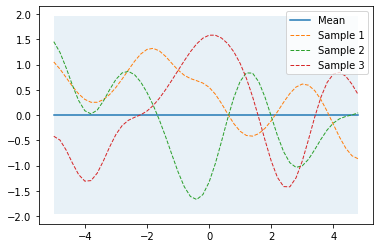

In [2]:
%matplotlib inline

#from gaussian_processes_util import plot_gp

# Finite number of points
X = np.arange(-5, 5, 0.2).reshape(-1, 1)
Y=np.arange(-5,5,0.5).reshape(-1, 1)


# Mean and covariance of the prior
mu = np.zeros(X.shape)
cov = kernel(X, X)
print(X.shape)

print(np.sum(X**2, 1).reshape(-1, 1).shape)

# Draw three samples from the prior
samples = np.random.multivariate_normal(mu.ravel(), cov, 3)
#print(np.shape(samples))
# Plot GP mean, confidence interval and samples
X = X.ravel()
mu = mu.ravel()

uncertainty = 1.96 * np.sqrt(np.diag(cov))
    
plt.fill_between(X, mu + uncertainty, mu - uncertainty, alpha=0.1)
plt.plot(X, mu, label='Mean')
for i, sample in enumerate(samples):
    plt.plot(X, sample, lw=1, ls='--', label=f'Sample {i+1}')

plt.legend()




### Prediction from noise-free training data

To compute the sufficient statistics i.e. mean and covariance of the posterior predictive distribution we implement Equations $(4)$ and $(5)$

In [15]:
from numpy.linalg import inv

def posterior_predictive(X_s, X_train, Y_train, l=1.0, sigma_f=1.0, sigma_y=1e-8):
    '''
    Computes the suffifient statistics of the GP posterior predictive distribution 
    from m training data X_train and Y_train and n new inputs X_s.
    
    Args:
        X_s: New input locations (n x d).
        X_train: Training locations (m x d).
        Y_train: Training targets (m x 1).
        l: Kernel length parameter.
        sigma_f: Kernel vertical variation parameter.
        sigma_y: Noise parameter.
    
    Returns:
        Posterior mean vector (n x d) and covariance matrix (n x n).
    '''
    K = kernel(X_train, X_train, l, sigma_f) + sigma_y**2 * np.eye(len(X_train))
    K_s = kernel(X_train, X_s, l, sigma_f)
    K_ss = kernel(X_s, X_s, l, sigma_f) 
    K_inv = inv(K)
    
    # Equation (4)
    mu_s =  K_s.T.dot(K_inv).dot(Y_train) # optionnel + np.mean(X_s)

    # Equation (5)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s, cov_s

and apply them to noise-free training data `X_train` and `Y_train`. The following example draws three samples from the posterior predictive and plots them along with the mean, confidence interval and training data. In a noise-free model, variance at the training points is zero and all random functions drawn from the posterior go through the trainig points. 

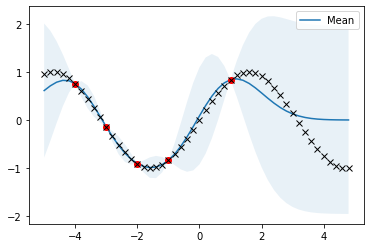

In [16]:
# Noise free training data X_s
X = np.arange(-5, 5, 0.2).reshape(-1, 1) # X_test 

X_train = np.array([-4, -3, -2, -1, 1]).reshape(-1, 1)
Y_train = np.sin(X_train)

# Compute mean and covariance of the posterior predictive distribution
mu_s, cov_s = posterior_predictive(X, X_train, Y_train)


#samples = np.random.multivariate_normal(mu_s.ravel(), cov_s, 3)

# plot 
X = X.ravel()
mu_s = mu_s.ravel()

uncertainty = 1.96 * np.sqrt(np.diag(cov_s))
    
plt.fill_between(X, mu_s + uncertainty, mu_s - uncertainty, alpha=0.1)
plt.plot(X, mu_s, label='Mean')# prédiction GPR
#for i, sample in enumerate(samples):
#    plt.plot(X, sample, lw=1, ls='--', label=f'Sample {i+1}')
plt.plot(X_train, Y_train, 'ro')
plt.legend()
####
Y_test = np.sin(X)
plt.plot(X, Y_test, 'kx')

### Prediction from noisy training data

If some noise is included in the model, training points are only approximated and the variance at the training points is non-zero.

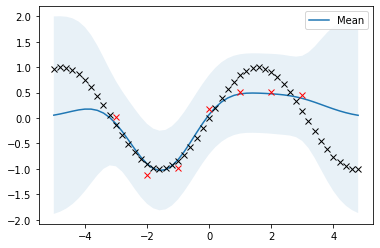

In [19]:
noise = 0.5
X = np.arange(-5, 5, 0.2).reshape(-1, 1)

# Noisy training data
X_train = np.arange(-3, 4, 1).reshape(-1, 1)
Y_train = np.sin(X_train) + noise * np.random.randn(*X_train.shape)

# Compute mean and covariance of the posterior predictive distribution
mu_s, cov_s = posterior_predictive(X, X_train, Y_train, sigma_y=noise)

samples = np.random.multivariate_normal(mu_s.ravel(), cov_s, 3)

X = X.ravel()
mu_s = mu_s.ravel()

uncertainty = 1.96 * np.sqrt(np.diag(cov_s))
    
plt.fill_between(X, mu_s + uncertainty, mu_s - uncertainty, alpha=0.1)
plt.plot(X, mu_s, label='Mean')
#for i, sample in enumerate(samples):
#    plt.plot(X, sample, lw=1, ls='--', label=f'Sample {i+1}')
plt.plot(X_train, Y_train, 'rx')
####
Y_test = np.sin(X)
plt.plot(X, Y_test, 'kx')
plt.legend()

### Effect of kernel parameters and noise parameter

The following example shows the effect of kernel parameters $l$ and $\sigma_f$ as well as the noise parameter $\sigma_y$. Higher $l$ values lead to smoother functions and therefore to coarser approximations of the training data. Lower $l$ values make functions more wiggly with wide confidence intervals between training data points. $\sigma_f$ controls the vertical variation of functions drawn from the GP. This can be seen by the wide confidence intervals outside the training data region in the right figure of the second row. $\sigma_y$ represents the amount of noise in the training data. Higher $\sigma_y$ values make more coarse approximations which avoids overfitting to noisy data.

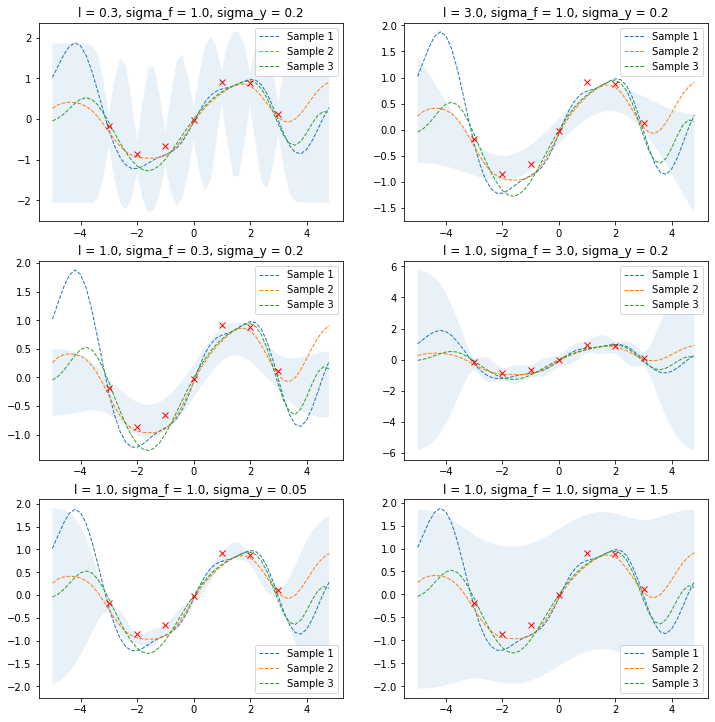

In [59]:
X = np.arange(-5, 5, 0.2).reshape(-1, 1)
# Noisy training data
X_train = np.arange(-3, 4, 1).reshape(-1, 1)
Y_train = np.sin(X_train) + noise * np.random.randn(*X_train.shape)

#print(sigma_f)


params = [
    (0.3, 1.0, 0.2),
    (3.0, 1.0, 0.2),
    (1.0, 0.3, 0.2),
    (1.0, 3.0, 0.2),
    (1.0, 1.0, 0.05),
    (1.0, 1.0, 1.5),
]

plt.figure(figsize=(12, 5))

for i, (l, sigma_f, sigma_y) in enumerate(params):
    mu_s, cov_s = posterior_predictive(X, X_train, Y_train, l=l, sigma_f=sigma_f, sigma_y=sigma_y)
    plt.subplot(3, 2, i + 1)
    plt.subplots_adjust(top=2)
    plt.title(f'l = {l}, sigma_f = {sigma_f}, sigma_y = {sigma_y}')
    #plot_gp
    Xr = X.ravel()
    mu_sr = mu_s.ravel()

    uncertainty = 1.96 * np.sqrt(np.diag(cov_s))
    
    plt.fill_between(Xr, mu_sr + uncertainty, mu_sr - uncertainty, alpha=0.1)
    
    for i, sample in enumerate(samples):
        plt.plot(X, sample, lw=1, ls='--', label=f'Sample {i+1}')
    plt.plot(X_train, Y_train, 'rx')
    plt.legend()

Optimal values for these parameters can be estimated by maximizing the log marginal likelihood which is given by<sup>[1][3]</sup>

$$
\log p(\mathbf{y} \lvert \mathbf{X}) = 
\log \mathcal{N}(\mathbf{y} \lvert \boldsymbol{0},\mathbf{K}_y) =
-\frac{1}{2} \mathbf{y}^T \mathbf{K}_y^{-1} \mathbf{y} 
-\frac{1}{2} \log \begin{vmatrix}\mathbf{K}_y\end{vmatrix} 
-\frac{N}{2} \log(2\pi) \tag{7}
$$

In the following we will minimize the negative log marginal likelihood w.r.t. parameters $l$ and $\sigma_f$, $\sigma_y$ is set to the known noise level of the data. If the noise level is unknown, $\sigma_y$ can be estimated as well along with the other parameters. 

1.736606557146117 1.0281878099975292


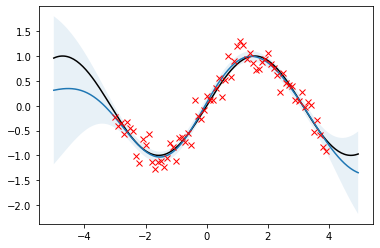

In [52]:
from operator import itemgetter
import numpy as np
import matplotlib.pyplot as plt

from numpy.linalg import cholesky, det, lstsq
from scipy.optimize import minimize
from functools import partial

np.random.seed(777)

noise=0.2

X = np.arange(-5, 5, 0.05).reshape(-1, 1) # X_test
# Noisy training data
X_train = np.arange(-3, 4, 0.1).reshape(-1, 1)
Y_train = np.sin(X_train) + noise * np.random.normal(0,1,X_train.shape)



def nll_fn(X_train, Y_train, noise, theta):
    '''
    Returns a function that computes the negative log marginal
    likelihood for training data X_train and Y_train and given 
    noise level.
    
    Args:
        X_train: training locations (m x d).
        Y_train: training targets (m x 1).
        noise: known noise level of Y_train.
        naive: if True use a naive implementation of Eq. (7), if 
               False use a numerically more stable implementation. 
        
    Returns:
        Minimization objective.
    '''
   
    # Naive implementation of Eq. (7). Works well for the examples 
    # in this article but is numerically less stable compared to 
    # the implementation in nll_stable below.
    K = kernel(X_train, X_train, l=theta[0], sigma_f=theta[1]) + noise**2 * np.eye(len(Y_train))
    likelihood=0.5 * np.log(det(K)) +  0.5 * Y_train.T.dot(inv(K).dot(Y_train)) 
    + 0.5 * len(Y_train) * np.log(2*np.pi)
    return likelihood.ravel()

    



# Minimize the negative log-likelihood w.r.t. parameters l and sigma_f.
# We should actually run the minimization several times with different
# initializations to avoid local minima but this is skipped here for
# simplicity.

objective = partial(nll_fn, X_train, Y_train, noise)
optima = [minimize(objective,[1, 1], bounds=((1e-5, None), (1e-5, None)),method='L-BFGS-B').x]
#optima = [minimize(objective,[1, 1], bounds=((1e-5, None), (1e-5, None)),method='Powell').x]

N_restarts=10
objective =partial(nll_fn, X_train, Y_train, noise)

for iteration in range(N_restarts):
    optima.append(minimize(objective,[np.random.uniform(0.5,2.5,None), np.random.uniform(0.5,2,None)], bounds=((1e-5, None), (1e-5, None)),method='L-BFGS-B').x)
    #optima.append(minimize(objective,[np.random.uniform(0.5,1.5,None), np.random.uniform(0.5,1.5,None)], bounds=((1e-5, None), (1e-5, None)),method='Powell').x)
    lml_values=list(map(itemgetter(1), optima))
    l_opt=optima[np.argmin(lml_values)][0]
    sigma_f_opt=optima[np.argmin(lml_values)][1]
    #print(l_opt)
    #print(sigma_f_opt)

# Store the optimization results in global variables so that we can
# compare it later with the results from other implementations.
#l_opt, sigma_f_opt = res.x
print(l_opt, sigma_f_opt)

# Compute the prosterior predictive statistics with optimized kernel parameters and plot the results
mu_s, cov_s = posterior_predictive(X, X_train, Y_train, l=l_opt, sigma_f=sigma_f_opt, sigma_y=noise)

#plot 
Xr = X.ravel()
mu_sr = mu_s.ravel()

uncertainty = 1.96 * np.sqrt(np.diag(cov_s))
plt.fill_between(Xr, mu_sr + uncertainty, mu_sr - uncertainty, alpha=0.1)


plt.plot(X,np.sin(X),'k')
plt.plot(Xr,mu_sr)

plt.plot(X_train, Y_train, 'rx')

In [45]:
l_values = np.linspace(1, 3, 5)
print(l_values)

sigmaf_values = np.linspace(1, 2, 5)
print(sigmaf_values)
L, Sigmaf = np.meshgrid(l_values, sigmaf_values)
print(L)
print(Sigmaf)

[1.  1.5 2.  2.5 3. ]
[1.   1.25 1.5  1.75 2.  ]
[[1.  1.5 2.  2.5 3. ]
 [1.  1.5 2.  2.5 3. ]
 [1.  1.5 2.  2.5 3. ]
 [1.  1.5 2.  2.5 3. ]
 [1.  1.5 2.  2.5 3. ]]
[[1.   1.   1.   1.   1.  ]
 [1.25 1.25 1.25 1.25 1.25]
 [1.5  1.5  1.5  1.5  1.5 ]
 [1.75 1.75 1.75 1.75 1.75]
 [2.   2.   2.   2.   2.  ]]


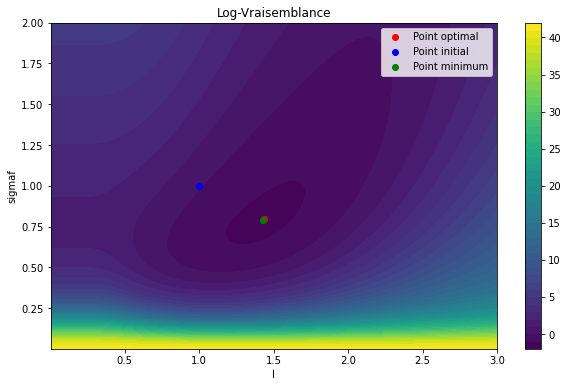

In [46]:
# Créer une grille de valeurs pour l et sigmaf
l_values = np.linspace(0.001, 3, 100)
sigmaf_values = np.linspace(0.001, 2, 100)
L, Sigmaf = np.meshgrid(l_values, sigmaf_values)
Z = np.zeros_like(L)



# Calculer la log-vraisemblance pour chaque paire (l, sigmaf)
for i in range(len(l_values)):
    for j in range(len(sigmaf_values)):
        Z[i, j] = nll_fn(X_train, Y_train, noise, [L[i, j], Sigmaf[i, j]])

# Tracer les contours
plt.figure(figsize=(10, 6))
cp = plt.contourf(L, Sigmaf, Z, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('l')
plt.ylabel('sigmaf')
plt.title('Log-Vraisemblance')

# Superposer le point optimal
plt.scatter(l_opt, sigma_f_opt, color='red', label='Point optimal')
# Superposer le point intial
plt.scatter(1, 1, color='blue', label='Point initial')
plt.legend()

# Trouver l'indice du minimum de Z
min_index = np.unravel_index(np.argmin(Z), Z.shape)
l_min = L[min_index]
sigmaf_min = Sigmaf[min_index]

# Indice du minimum
plt.scatter(l_min, sigmaf_min, color='green', label='Point minimum')
plt.legend()
plt.show()

Note how the true sine wave is approximated much better after parameter optimization.

## Libraries that implement GPs

This section shows two examples of libraries that provide implementations of GPs. I'll provide only a minimal setup here, just enough for reproducing the above results. For further details please consult the documentation of these libraries.

### Scikit-learn

Scikit-learn provides a `GaussianProcessRegressor` for implementing [GP regression models](http://scikit-learn.org/stable/modules/gaussian_process.html#gaussian-process-regression-gpr). It can be configured with [pre-defined kernels and user-defined kernels](http://scikit-learn.org/stable/modules/gaussian_process.html#gp-kernels). Kernels can also be composed. The squared exponential kernel is the `RBF` kernel in scikit-learn. The `RBF` kernel only has a `length_scale` parameter which corresponds to the $l$ parameter above. To have a $\sigma_f$ parameter as well, we have to compose the `RBF` kernel with a `ConstantKernel`.

1.736613779053978 1.028199174308458


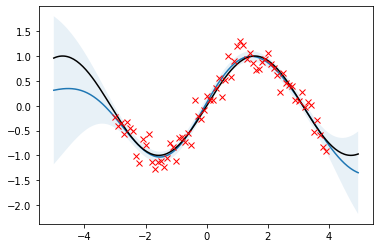

In [54]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF

rbf = ConstantKernel(1.0) * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=rbf, alpha=noise**2)

# Reuse training data from previous 1D example
gpr.fit(X_train, Y_train)

# Compute posterior predictive mean and covariance
mu_s, cov_s = gpr.predict(X, return_cov=True)

# Obtain optimized kernel parameters
l = gpr.kernel_.k2.get_params()['length_scale']
sigma_f = np.sqrt(gpr.kernel_.k1.get_params()['constant_value'])

print(l,sigma_f)
# Compare with previous results
#assert(np.isclose(l_opt, l))
#assert(np.isclose(sigma_f_opt, sigma_f))

# Plot the results
#plot_gp(mu_s, cov_s, X, X_train=X_train, Y_train=Y_train)

Xr = X.ravel()
mu_sr = mu_s.ravel()

uncertainty = 1.96 * np.sqrt(np.diag(cov_s))
plt.fill_between(Xr, mu_sr + uncertainty, mu_sr - uncertainty, alpha=0.1)

plt.plot(Xr,mu_sr)
plt.plot(X,np.sin(X),'k')
plt.plot(X_train, Y_train, 'rx')

## GPR and Black-Scholes pricing formula : 1 training input

In [2]:
import scipy.stats as st
import numpy as np
import numpy.random as npr
from numpy.linalg import cholesky, det, lstsq
from scipy.optimize import minimize
from functools import partial
from numpy.linalg import inv
import matplotlib.pyplot as plt

In [3]:
def BS_model_path(S0,r,sigma,T,nSteps,nPaths):
    
    # S0 spot price
    # r instantenous interest rate
    # sigma volatility
    # T maturity
    # nSteps number of time steps
    # nPaths : number of possible scenarios
    dt=T/(nSteps) # time step
    Log_returns=(r-sigma**2/2)*dt+ sigma*np.sqrt(dt)*npr.normal(0,1,(nPaths,nSteps)) # brownian increments
    
    Log_returns=np.concatenate((np.ones((nPaths,1))*np.log(S0),Log_returns),axis=1)
    
    Log_path=np.cumsum(Log_returns, axis=1)# concatenate with S0
    S= np.exp(Log_path) 
    t=np.matrix(np.linspace(0,T,nSteps+1))
    
    return t,S



Text(0, 0.5, 'S_t')

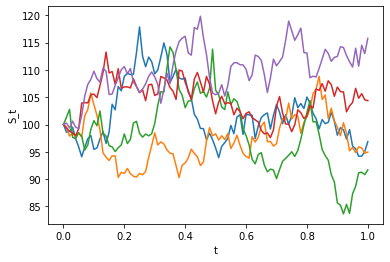

In [110]:
BS_PATH=BS_model_path(100,0.05,0.2,1,100, 5);

plt.plot(BS_PATH[0].T,BS_PATH[1].T)
plt.xlabel('t')
plt.ylabel('S_t')

## S\&P

In [113]:
import pandas as pd
import yfinance as yf
from pandas_datareader import DataReader
from datetime import datetime



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,   2.,   4.,
          4.,   6.,   4.,   5.,  13.,  18.,  19.,  25.,  31.,  40.,  52.,
         88.,  84., 129., 100.,  93.,  86.,  50.,  43.,  37.,  31.,  16.,
         11.,  10.,   5.,   6.,   2.,   1.,   5.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.]),
 array([-0.04210687, -0.04039409, -0.03868131, -0.03696853, -0.03525575,
        -0.03354297, -0.03183019, -0.03011741, -0.02840463, -0.02669185,
        -0.02497907, -0.02326629, -0.02155351, -0.01984073, -0.01812795,
        -0.01641517, -0.01470239, -0.01298961, -0.01127683, -0.00956405,
        -0.00785128, -0.0061385 , -0.00442572, -0.00271294, -0.00100016,
         0.00071262,  0.0024254 ,  0.00413818,  0.00585096,  0.00756374,
         0.00927652,  0.0109893 ,  0.01270208,  0.01441486,  0.01612764,
         0.01784042,  0.0195532 ,  0.02126598,  0.02297876,  0.02469154,
         0.02640432,  0.0281171 ,  0.02982988,  0.03154266,  0.03325544,
         0.03496822

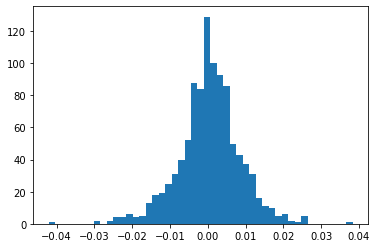

In [128]:
spy = yf.download('SPY',  datetime(2012,1,1), datetime(2015,1,1))

# Log returns
#spy_returns = pd.DataFrame(np.diff(np.log(spy['Adj Close'].values))) #log returns
returns=yf.download('SPY', datetime(2012,1,1), datetime(2016,2,1)).loc[:,'Close'].pct_change()[1:]
 
plt.hist(returns,'auto')    
#x = np.array([1, 2, 4, 7, 0])
#np.diff(x)
#array([ 1,  2,  3, -7])
#spy_returns.hist(bins='auto')
#spy_returns.index = spy.index[1:spy.index.shape[0]]
#spy_returns.columns = ['S&P500 Returns']
#print(spy_returns)
#plt.figure(figsize=(15,5));
#plt.plot(spy_returns);
#plt.ylabel('Returns');
#plt.title('S&P500 Returns');
#plt.show();

In [60]:
import scipy.stats as st
import numpy as np
from numpy.linalg import cholesky, det, lstsq
from scipy.optimize import minimize
from functools import partial
from numpy.linalg import inv
import matplotlib.pyplot as plt


def bsformula(cp, s, k, rf, t, v, div):
        """ Price an option using the Black-Scholes model.
        cp: +1/-1 for call/put
        s: initial stock price
        k: strike price
        t: expiration time
        v: volatility
        rf: risk-free rate
        div: dividend
        """

        d1 = (np.log(s/k)+(rf-div+0.5*v*v)*t)/(v*np.sqrt(t))
        d2 = d1 - v*np.sqrt(t)

        optprice = (cp*s*np.exp(-div*t)*st.norm.cdf(cp*d1)) - (cp*k*np.exp(-rf*t)*st.norm.cdf(cp*d2))
        delta = cp*st.norm.cdf(cp*d1)
        vega  = s*np.sqrt(t)*st.norm.pdf(d1)
        gamma= st.norm.pdf(d1)/(s*v*np.sqrt(t))
        return optprice, delta, vega, gamma


vbsformula=np.vectorize(bsformula)  




def European_Price_BS_MC(cp, s, k, rf, t, v, div, M):
        """ Price an option using the Black-Scholes model.
        cp: +1/-1 for call/put
        s: initial stock price
        k: strike price
        t: expiration time
        v: volatility
        rf: risk-free rate
        div: dividend
        M: Monte Carlo Sample size
        """

        G=npr.normal(0,1,M)
    
        S=s*np.exp((rf-div - 0.5*v**2)*t+ v*np.sqrt(t)*G)
        
        if cp==1 :
            payoff= np.exp(-rf*t)*np.maximum(S-k,0)
        else :    
            payoff= np.exp(-rf*t)*np.maximum(k-S,0)
            
        MC_price=np.mean(payoff)
        MC_error= 1.96*np.std(payoff)/np.sqrt(M)
        
        return MC_price


vbsformula=np.vectorize(bsformula)  

vEuropean_Price_BS_MC=np.vectorize(European_Price_BS_MC)

In [61]:
def kernel(X1, X2, l=1.0, sigma_f=1):
    '''
    Isotropic squared exponential kernel. Computes 
    a covariance matrix from points in X1 and X2.
    
    Args:
        X1: Array of m points (m x d).
        X2: Array of n points (n x d).

    Returns:
        Covariance matrix (m x n).
    '''
    sqdist = np.sum(X1**2, 1).reshape(-1, 1) + np.sum(X2**2, 1) - 2 * np.dot(X1, X2.T)
    return sigma_f**2 * np.exp(-0.5 / l**2 * sqdist)


In [62]:
def posterior_predictive(X_s, X_train, Y_train, l=1.0, sigma_f=1.0, sigma_y=1e-8):
    '''
    Computes the suffifient statistics of the GP posterior predictive distribution 
    from m training data X_train and Y_train and n new inputs X_s.
    
    Args:
        X_s: New input locations (n x d).
        X_train: Training locations (m x d).
        Y_train: Training targets (m x 1).
        l: Kernel length parameter.
        sigma_f: Kernel vertical variation parameter.
        sigma_y: Noise parameter.
    
    Returns:
        Posterior mean vector (n x d) and covariance matrix (n x n).
    '''
    K = kernel(X_train, X_train, l, sigma_f) + sigma_y**2 * np.eye(len(X_train))
    K_s = kernel(X_train, X_s, l, sigma_f)
    K_ss = kernel(X_s, X_s, l, sigma_f) + sigma_y *  np.eye(len(X_s))
    K_inv = inv(K)
    
    # Equation (4)
    mu_s =  0 + K_s.T.dot(K_inv).dot(Y_train) # en pratique on prend mean(X_S)=0


    # Equation (5)
    cov_s = K_ss - K_s.T.dot(K_inv).dot(K_s)
    
    return mu_s, cov_s

## On fait varier un seul paramètre Spot S_0

&&&&&&
0.20039967950966048 25.18175847005964
*****
0.07712698202712168
[0.]
[-0.00017513]


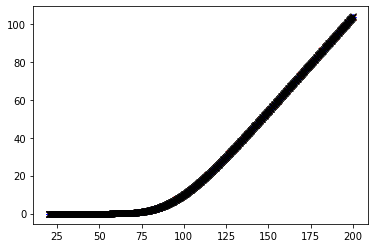

In [84]:
from operator import itemgetter
import numpy.random as npr

from numpy.linalg import cholesky, det, lstsq
from scipy.optimize import minimize
from functools import partial




lb_S = 20      # lower bound on domain
ub_S = 200          # upper bound on domain
training_number =  70# Number of training samples
testing_number =1000 # Number of testing samples
r=0.04
T=1
vol=0.2
Strike=100
div=0
noise=1e-2
l_opt=1
sigma_f_opt=1
M=10**5

#X_train = np.random.random(training_number).reshape(training_number, 1)
X_train = np.linspace(0,1,training_number).reshape(training_number, 1)
Y_train =vEuropean_Price_BS_MC(1, lb_S+(ub_S-lb_S)*X_train, Strike, r, 1, vol, 0,M).reshape(training_number, 1)
#Y_train =vbsformula(1, X_train, Strike, r, 1, vol, 0)[0].reshape(training_number, 1)



#X_test = np.random.random(testing_number).reshape(testing_number, 1)
X_test = np.linspace(0,1,testing_number).reshape(testing_number, 1)

Y_test = vEuropean_Price_BS_MC(1, lb_S+(ub_S-lb_S)*X_test, Strike, r, 1, vol, 0,M).reshape(testing_number, 1)
#Y_test = vbsformula(1, X_test, Strike, r, 1, vol, 0)[0].reshape(testing_number, 1)



def nll_fn(X_train, Y_train, noise, theta):
    '''
    Returns a function that computes the negative log marginal
    likelihood for training data X_train and Y_train and given 
    noise level.
    
    Args:
        X_train: training locations (m x d).
        Y_train: training targets (m x 1).
        noise: known noise level of Y_train.
        naive: if True use a naive implementation of Eq. (7), if 
               False use a numerically more stable implementation. 
        
    Returns:
        Minimization objective.
    '''
   
   
    K = kernel(X_train, X_train, l=theta[0], sigma_f=theta[1]) + noise**2 * np.eye(len(Y_train))
    #L = np.linalg.cholesky(K)  # Décomposition de Cholesky pour éviter l'inversion
    # Résolution plus stable que l'inversion
    #alpha = np.linalg.solve(L.T, np.linalg.solve(L, Y_train))

    likelihood=0.5 * np.log(det(K)) +  0.5 * Y_train.T.dot(inv(K).dot(Y_train)) + 0.5 * len(Y_train) * np.log(2*np.pi)
    #likelihood=0.5 * np.log(det(K)) + 0.5 * Y_train.T.dot(alpha) + 0.5 * len(Y_train) * np.log(2 * np.pi)
    
    return likelihood.ravel()

    



# Minimize the negative log-likelihood w.r.t. parameters l and sigma_f.
# We should actually run the minimization several times with different
# initializations to avoid local minima but this is skipped here for
# simplicity.




objective = partial(nll_fn, X_train, Y_train, noise)
#res = minimize(objective,[1, 1], bounds=((1e-5, None), (1e-5, None)),method='Powell')
optima=[minimize(objective,[1, 1], bounds=((1e-5, None), (1e-5, None)),method='L-BFGS-B').x]

N_restarts=100
objective =partial(nll_fn, X_train, Y_train, noise)

for iteration in range(N_restarts):
    optima.append(minimize(objective,[np.random.uniform(0.5,2,None), np.random.uniform(40,50,None)], bounds=((1e-5, None), (1e-5, None)),method='L-BFGS-B').x)
    #optima.append(minimize(objective,[np.random.uniform(0,2,None), np.random.uniform(0,2,None)], bounds=((1e-5, None), (1e-5, None)),method='Powell').x)
    lml_values=list(map(itemgetter(1), optima))
    l_opt=optima[np.argmin(lml_values)][0]
    sigma_f_opt=optima[np.argmin(lml_values)][1]


   

# Store the optimization results in global variables so that we can
# compare it later with the results from other implementations.
#l_opt, sigma_f_opt = res.x
print('&&&&&&')
print(l_opt, sigma_f_opt)


# Store the optimization results in global variables so that we can
# compare it later with the results from other implementations.
#l_opt, sigma_f_opt = res.x
#print(l_opt, sigma_f_opt)

# Compute the prosterior predictive statistics with optimized kernel parameters and plot the results
mu_s, cov_s = posterior_predictive(X_test, X_train, Y_train, l=l_opt, sigma_f=sigma_f_opt, sigma_y=noise)


Xr = lb_S+(ub_S-lb_S)*X_test.ravel()

mu_sr = mu_s.ravel()

X_test=lb_S+(ub_S-lb_S)*X_test.ravel()
uncertainty = 1.96 * np.sqrt(np.diag(cov_s))

plt.fill_between(Xr, mu_sr + uncertainty, mu_sr - uncertainty, alpha=1)



plt.plot(X_test,mu_s,'b+')

plt.plot(lb_S+(ub_S-lb_S)*X_train, Y_train, 'rx')



RMSE=np.sqrt(np.mean(((Y_test-mu_s))**2))

print('*****')
print(RMSE)
print(Y_test[3])
print(mu_s[3])


plt.plot(X_test, Y_test, 'kx')


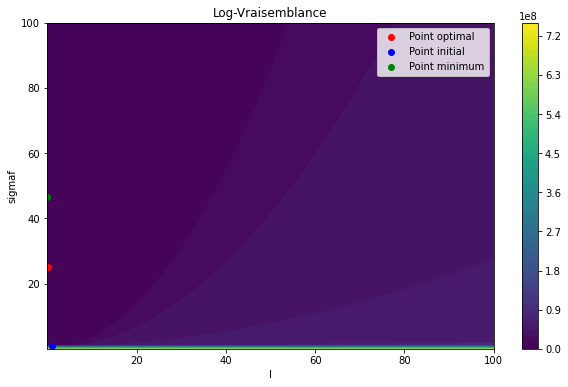

In [85]:
l_values = np.linspace(0.001, 100, 100)
sigmaf_values = np.linspace(0.001, 100, 100)
L, Sigmaf = np.meshgrid(l_values, sigmaf_values)
Z = np.zeros_like(L)




# Calculer la log-vraisemblance pour chaque paire (l, sigmaf)
for i in range(len(l_values)):
    for j in range(len(sigmaf_values)):
        Z[i, j] = nll_fn(X_train, Y_train, noise, [L[i, j], Sigmaf[i, j]])

# Tracer les contours
plt.figure(figsize=(10, 6))
cp = plt.contourf(L, Sigmaf, Z, levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('l')
plt.ylabel('sigmaf')
plt.title('Log-Vraisemblance')

# Superposer le point optimal
plt.scatter(l_opt, sigma_f_opt, color='red', label='Point optimal')
# Superposer le point intial
plt.scatter(1, 1, color='blue', label='Point initial')
plt.legend()

# Trouver l'indice du minimum de Z
min_index = np.unravel_index(np.argmin(Z), Z.shape)
l_min = L[min_index]
sigmaf_min = Sigmaf[min_index]

# Indice du minimum
plt.scatter(l_min, sigmaf_min, color='green', label='Point minimum')
plt.legend()
plt.show()


## Apprendre le Delta 

0.0075289842545543115


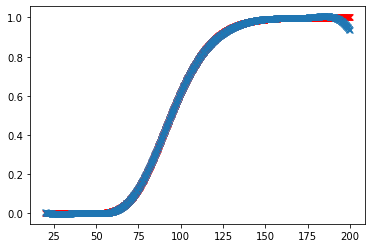

In [86]:
import scipy as sp

# Delta GPR
K_prime = np.zeros([len(X_test), len(X_train)])

X_test = np.linspace(0,1,testing_number).reshape(testing_number, 1)

K = kernel(X_train, X_train, l=l_opt, sigma_f=sigma_f_opt) + noise * np.eye(training_number)

K_test_train=kernel(X_test, X_train, l=l_opt, sigma_f=sigma_f_opt)




for i in range(len(X_test)):
    for j in range(len(X_train)):
     
        K_prime[i, j] = (1.0/l_opt**2) * (X_train[j] - X_test[i]) * K_test_train[i, j]
        



# On fait par Cholesky au lieu d'inverser
K_y = K + np.eye(training_number) * noise
#L = sp.linalg.cho_factor(K_y)
#alpha_p = sp.linalg.cho_solve(np.transpose(L), Y_train)

#Delta_GPR= np.dot(K_prime, alpha_p)/ (S_ub - S_lb)

Delta_GPR=np.dot(K_prime,np.dot(inv(K),Y_train)) / (ub_S - lb_S)

#Delta_GPR=np.dot(K_prime, alpha_p)/ (ub_S - lb_S)



Delta_test = vbsformula(1, lb_S+(ub_S-lb_S)*X_test, Strike, r, 1, vol, 0)[1]


RMSE_Delta=np.sqrt(np.mean(((Delta_test-Delta_GPR))**2))

print(RMSE_Delta)


plt.plot(lb_S+(ub_S-lb_S)*X_test,Delta_test,'xr')
plt.plot(lb_S+(ub_S-lb_S)*X_test,Delta_GPR,'x')

## Apprendre le gamma

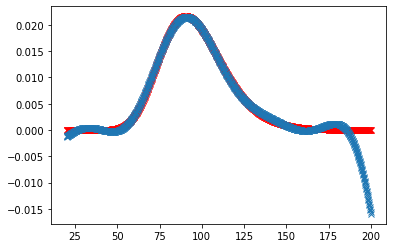

In [87]:
import scipy as sp

# Delta GPR
K_prime = np.zeros([len(X_test), len(X_train)])
K_second = np.zeros([len(X_test), len(X_train)])

X_test = np.linspace(0,1,testing_number).reshape(testing_number, 1)

K = kernel(X_train, X_train, l=l_opt, sigma_f=sigma_f_opt) + noise * np.eye(training_number)

K_test_train=kernel(X_test, X_train, l=l_opt, sigma_f=sigma_f_opt)




for i in range(len(X_test)):
    for j in range(len(X_train)):
     
        K_prime[i, j] = (1.0/l_opt**2) * (X_train[j] - X_test[i]) * K_test_train[i, j]
        K_second[i,j]= ((1.0/l_opt**4) * (X_train[j] - X_test[i])**2 - 1.0/l_opt**2) * K_test_train[i, j]



# On fait par Cholesky au lieu d'inverser
K_y = K + np.eye(training_number) * noise
#L = sp.linalg.cho_factor(K_y)
#alpha_p = sp.linalg.cho_solve(np.transpose(L), Y_train)



Gamma_GPR=np.dot(K_second,np.dot(inv(K_y),Y_train)) / ((ub_S - lb_S)**2)


Gamma_test = vbsformula(1, lb_S+(ub_S-lb_S)*X_test, Strike, r, 1, vol, 0)[3]



RMSE_Gamma=np.sqrt(np.mean(((Gamma_test-Gamma_GPR))**2))



plt.figure()

plt.plot(lb_S+(ub_S-lb_S)*X_test,Gamma_test,'xr')
plt.plot(lb_S+(ub_S-lb_S)*X_test,Gamma_GPR,'x')

## On fait varier le spot S0 et la maturité T

In [88]:
from operator import itemgetter
import numpy.random as npr

from numpy.linalg import cholesky, det, lstsq
from scipy.optimize import minimize
from functools import partial




lb_S = 70      # lower bound on domain
ub_S = 120  # upper bound on domain
lb_T=0.5
ub_T=3

training_number =  10# Number of training samples
testing_number =100 # Number of testing samples
r=0.04
T=1
vol=0.2
Strike=100
div=0
noise=1e-2




X_train_S = np.linspace(0, 1, training_number)
X_train_T = np.linspace(0, 1, training_number)
X_train = np.array(np.meshgrid(X_train_S, X_train_T)).T.reshape(-1,2)
print(X_train.shape)
X_test_S = np.linspace(0, 1, testing_number)
X_test_T = np.linspace(0, 1, testing_number)
X_test = np.array(np.meshgrid(X_test_S, X_test_T)).T.reshape(-1,2)



Y_train =vbsformula(1, lb_S+(ub_S-lb_S)*X_train[:,0], Strike, r, lb_T+(ub_T-lb_T)*X_train[:,1], vol, 0)[0].reshape(training_number**2, 1)


Y_test =vbsformula(1, lb_S+(ub_S-lb_S)*X_test[:,0], Strike, r, lb_T+(ub_T-lb_T)*X_test[:,1], vol, 0)[0].reshape(testing_number**2, 1)


def nll_fn(X_train, Y_train, noise, theta):
    '''
    Returns a function that computes the negative log marginal
    likelihood for training data X_train and Y_train and given 
    noise level.
    
    Args:
        X_train: training locations (m x d).
        Y_train: training targets (m x 1).
        noise: known noise level of Y_train.
        naive: if True use a naive implementation of Eq. (7), if 
               False use a numerically more stable implementation. 
        
    Returns:
        Minimization objective.
    '''
   
   
    K = kernel(X_train, X_train, l=theta[0], sigma_f=theta[1]) + noise**2 * np.eye(len(Y_train))
   
    likelihood=0.5 * np.log(det(K)) +  0.5 * Y_train.T.dot(inv(K).dot(Y_train)) + 0.5 * len(Y_train) * np.log(2*np.pi)
    
    return likelihood.ravel()

    



# Minimize the negative log-likelihood w.r.t. parameters l and sigma_f.
# We should actually run the minimization several times with different
# initializations to avoid local minima but this is skipped here for
# simplicity.




objective = partial(nll_fn, X_train, Y_train, noise)
#optima = minimize(objective,[1, 1], bounds=((1e-5, None), (1e-5, None)),method='Powell')
optima=[minimize(objective,[1, 1], bounds=((1e-5, None), (1e-5, None)),method='L-BFGS-B').x]

N_restarts=40
objective =partial(nll_fn, X_train, Y_train, noise)

for iteration in range(N_restarts):
    optima.append(minimize(objective,[np.random.uniform(0,2,None), np.random.uniform(0,2,None)], bounds=((1e-5, None), (1e-5, None)),method='L-BFGS-B').x)
    #optima.append(minimize(objective,[np.random.uniform(0,2,None), np.random.uniform(0,2,None)], bounds=((1e-5, None), (1e-5, None)),method='Powell').x)
    lml_values=list(map(itemgetter(1), optima))
    l_opt=optima[np.argmin(lml_values)][0]
    
    sigma_f_opt=optima[np.argmin(lml_values)][1]


   

# Store the optimization results in global variables so that we can
# compare it later with the results from other implementations.
#l_opt, sigma_f_opt = res.x
print('&&&&&&')
print(l_opt, sigma_f_opt)


# Store the optimization results in global variables so that we can
# compare it later with the results from other implementations.
#l_opt, sigma_f_opt = res.x
#print(l_opt, sigma_f_opt)

# Compute the prosterior predictive statistics with optimized kernel parameters and plot the results
mu_s, cov_s = posterior_predictive(X_test, X_train, Y_train, l=l_opt, sigma_f=sigma_f_opt, sigma_y=noise)



#plt.fill_between(Xr, mu_sr + uncertainty, mu_sr - uncertainty, alpha=0.1)



#plt.plot(X_test,mu_s,'b+')

#plt.plot(lb_S+(ub_S-lb_S)*X_train, Y_train, 'rx')



RMSE=np.sqrt(np.mean(((Y_test-mu_s))**2))

print('*****')
print(RMSE)
print(Y_test[3])
print(mu_s[3])




(100, 2)


<ipython-input-88-6f0afb85f73f>:64: RuntimeWarning: divide by zero encountered in log
  likelihood=0.5 * np.log(det(K)) +  0.5 * Y_train.T.dot(inv(K).dot(Y_train)) + 0.5 * len(Y_train) * np.log(2*np.pi)
/Users/kebaiera/opt/anaconda3/lib/python3.8/site-packages/scipy/optimize/_numdiff.py:557: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0
/Users/kebaiera/opt/anaconda3/lib/python3.8/site-packages/numpy/linalg/linalg.py:2146: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/kebaiera/opt/anaconda3/lib/python3.8/site-packages/numpy/linalg/linalg.py:2146: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
<ipython-input-88-6f0afb85f73f>:64: RuntimeWarning: invalid value encountered in log
  likelihood=0.5 * np.log(det(K)) +  0.5 * Y_train.T.dot(inv(K).dot(Y_train)) + 0.5 * len(Y_train) * np.log(2*np.pi)


&&&&&&
1.8184257332175733 0.09907115545080059
*****
0.47525460502130096
[0.06145212]
[-1.68231455]


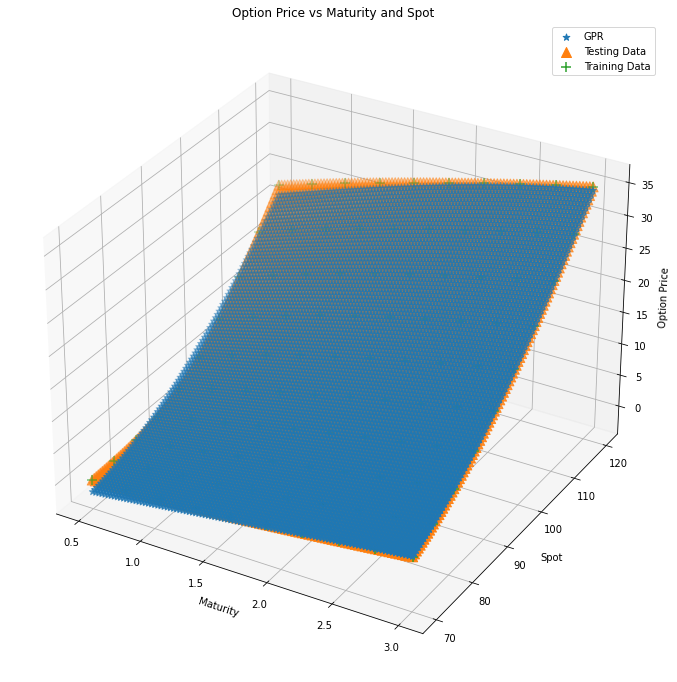

In [90]:
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

#Y_train_reshaped = Y_train.reshape(training_number, 1)
#Y_test_reshaped = Y_test.reshape(testing_number, 1)

fig = plt.figure(figsize=(15, 12))
ax = fig.add_subplot(111, projection='3d')

# Plot of training data
sc1 = ax.scatter(lb_T + (ub_T - lb_T) * X_test[:, 1],  lb_S + (ub_S - lb_S) * X_test[:, 0],mu_s, marker='*',s=50, label='GPR')

# Plot of testing data
sc2 = ax.scatter(lb_T + (ub_T - lb_T) * X_test[:, 1], lb_S + (ub_S - lb_S) * X_test[:, 0],Y_test,   marker='^',s=100, label='Testing Data')

#training data
sc2 = ax.scatter(lb_T + (ub_T - lb_T) * X_train[:, 1], lb_S + (ub_S - lb_S) * X_train[:, 0],Y_train,   marker='+',s=100, label='Training Data')

ax.set_xlabel('Maturity')
ax.set_zlabel('Option Price')
ax.set_ylabel('Spot')
ax.set_title('Option Price vs Maturity and Spot')

#cbar = fig.colorbar(sc1, ax=ax, label='Maturity')
ax.legend()
plt.show()
